# The Costless Collar — a quantitative teardown 🔬
### The Black-Scholes cap solver · the floor/cap split tests · a cost-sensitivity and break-even sweep · the ex-crash-window robustness check · a 20-seed synthetic clip-mechanics control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_protection%3F: Busted](https://img.shields.io/badge/Free_protection%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — a **zero-net-premium collar gives crash protection for free** — has a real mechanism (a floor financed by a cap) and a real published analogue (the CBOE 95-110 Collar Index). The job here is to price the stylized structure honestly, measure both legs, and ask whether the sign of the net effect is a property of the trade or a property of the sample.

> ⚠️ **Data note.** No historical SPY option chain exists on yfinance — every collar leg here is a Black-Scholes approximation priced off trailing realized volatility, our proxy for implied vol. SPY daily OHLC+AdjClose 1993→2026, yfinance, cached. No survivorship (SPY is a rules-based index ETF). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `44daf42aa058`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from costless_collar import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DAILY = data.load_real()
    MF = data.month_frame(DAILY)
    CAPS = st.collar_caps(MF["vol_in"], put_otm=data.PUT_OTM, r=data.RF_ANNUAL, T=data.OPTION_T)
    MF = MF.join(CAPS.rename("cap_pct"))
    COLL5 = st.collar_returns(MF["spy_ret"], MF["cap_pct"], put_otm=data.PUT_OTM, cost_bps=5.0)
    DF = pd.concat([MF, COLL5], axis=1)
else:
    DAILY = MF = CAPS = DF = None
print("real cache present:", HAVE_REAL, "| months on tape:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'spy_rows': 8410, 'spy_start': '1993-02-01', 'spy_end': '2026-06-30', 'fp_spy': '44daf42aa058', 'n_months': 397, 'm_start': '1993-06-30', 'm_end': '2026-06-30', 'cap_mean': 5.93, 'cap_min': 5.81, 'cap_max': 6.67, 'floor_pct': -5.0, 'vol_min': 5.6, 'vol_max': 70.7, 'vol_mean': 16.4, 'breakeven_bps': 3.84, 'cost_table': {5.0: (-2.3, -0.34, -0.33, 31.39), 10.0: (-12.3, -1.79, -1.76, 21.17), 15.0: (-22.3, -3.25, -3.2, 14.27), 20.0: (-32.3, -4.7, -4.63, 9.62)}, 'floor_n': 37, 'floor_cushion': 2.68, 'floor_t': 6.39, 'floor_worst_spy': -16.52, 'floor_worst_collar': -5.1, 'cap_n': 42, 'cap_share': 10.6, 'cap_cost': -1.83, 'cap_t': -7.67, 'cap_best_spy': 12.7, 'tw_spy': 29.95, 'tw_collar': 31.39, 'sharpe_spy': 0.57, 'sharpe_collar': 0.69, 'dd_spy': -50.8, 'dd_collar': -33.6, 'gfc_spy': -50.8, 'gfc_collar': -31.9, 'gfc_cut': 18.9, 'covid_spy': -19.4, 'covid_collar': -10.1, 'covid_cut': 9.4, 'exwin_n': 375, 'exwin_diff_bps': -10.8, 'exwin_t': -1.95, 'exwin_nwt': -2.1, 'exwin_tw_spy': 61.05, 'exwin_tw_collar': 44.83, 'exwin_sh_spy': 0.81, 'exwin_sh_collar': 0.86, 'syn_null_fires': 0, 'syn_planted_t': -5.08, 'syn_planted_sd': 1.03, 'syn_planted_fire': 20}


real cache present: True | months on tape: 397


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | floor cushion **+2.68 pts, t=6.39**; cap cost **-1.83 pts, t=-7.67**; ex-2008/2020 drag **NW t=-2.10** |
| **Tradability** | `FRAGILE` | break-even **3.84 bps/leg**; full-sample win concentrated in 22 of 397 months |
| **Free protection?** | `BUSTED` | the cap's cost clears t=-7.67 every time it binds, crash or no crash |

> 💡 In plain words: both halves of the trade are real; whether they net out in your favor is a bet on the future, not a property of the structure.

## 1 · The claim, steelmanned

Let $r_t$ be SPY's realized total return in month $t$, $f=-5\%$ the fixed put strike (floor), and $c_t$ the call strike (cap) solved so the Black-Scholes premiums of the put and call match at that month's trailing-realized-vol input $\sigma_t$ (known through the close of month $t-1$ — zero look-ahead). The collar's realized return is $\text{clip}(r_t,\,f,\,c_t)$ minus a 2-leg roll cost. The claims:

- **H₁ (protection).** In months where $r_t < f$, the collar materially and significantly beats SPY.
- **H₂ (cost).** In months where $r_t > c_t$, the collar materially and significantly trails SPY.
- **H₃ (free lunch).** Averaged over a realistic multi-decade sample, H₁ and H₂ net to (at worst) zero — the structure doesn't cost you money on net.

We find **H₁ and H₂ both strongly supported** (|t| > 6 each), and **H₃ unsupported once the 2008/2020 windows are excluded** (NW t = -2.10) — the full-sample near-wash is a property of *this particular sample containing 2 real crashes*, not of the trade's structure.

## 2 · So what? — inference design and the pricing model

**Pricing.** Both legs use the same Black-Scholes formula ($N(\cdot)$ via `math.erf`, no scipy dependency), the same constant risk-free rate (3%/yr) and the same trailing-realized-vol input for a given month — the call strike is found by bisection so `bs_call(K_call) == bs_put(K_put=0.95)`. This is a **flat-vol, skew-free approximation** of a real listed collar (see `docs/references.md` for the direction of the resulting bias).

**Inference.** Floor/cap bite tests are one-sample *t* on the paired monthly difference (collar − SPY), restricted to the months each leg actually binds. The full-sample and ex-crash-window drags additionally carry a **Newey-West (1987) 5→12-lag HAC** cross-check (monthly returns carry mild autocorrelation). The ex-crash-window split is **not** snooped to a favorable cut: it drops precisely the two windows the claim's own marketing invokes (2008 GFC, 2020 COVID) and *deliberately* leaves the 2000–2002 dot-com bear market in the "ex-crash" bucket.

## 3 · How we'd know — the protocol

- **Tape.** SPY daily OHLC+AdjClose 1993-02-01 → 2026-06-30 (8,410 rows); derived monthly sample 1993-06-30 → 2026-06-30 (397 months — the first ~4 months are a vol warm-up).
- **Model.** Put fixed at 5% OTM; call solved for equal BS premium at that month's trailing-63-session realized vol (known before the month begins — the study's one documented execution lag).
- **Headline.** Cost-sensitivity sweep (5/10/15/20 bps/leg) + a bisected break-even cost.
- **Anatomy.** Floor-bite and cap-bite one-sample *t* tests, restricted to the months each leg actually binds.
- **Aggregate.** Terminal wealth, Sharpe (excess of the same 3% cash rate) and max drawdown, full sample and the two named crash windows.
- **Robustness.** The ex-2008/2020-window drag test, HAC *t* checked across 4 lag choices.
- **Control.** Synthetic monthly GBM, no roll costs, a never-binding null band vs. an always-binding planted band; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The cap solver and its odd invariance

The modeled cap barely moves across a huge range of trailing realized vol — worth seeing directly, because it's counter-intuitive and we didn't smooth it away.

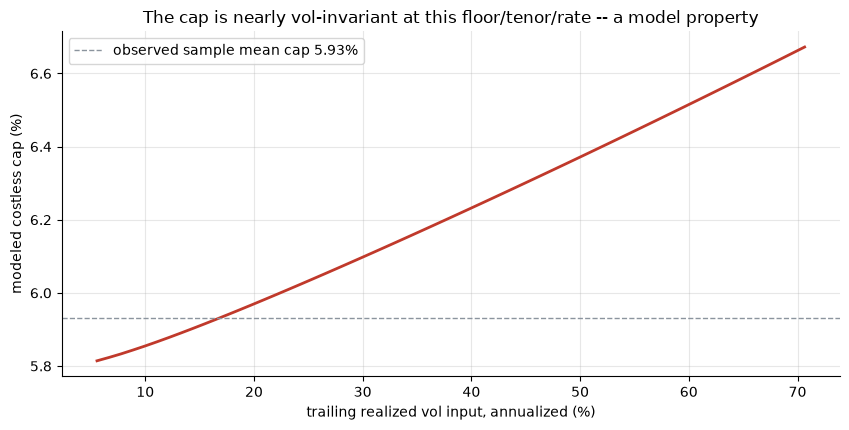

realized vol range on tape: 5.6%-70.7% (mean 16.4%)
modeled cap range: 5.81%-6.67% (mean 5.93%)


In [2]:
if HAVE_REAL:
    vmin, vmax, vmean = MF['vol_in'].min(), MF['vol_in'].max(), MF['vol_in'].mean()
    cmin, cmax, cmean = MF['cap_pct'].min(), MF['cap_pct'].max(), MF['cap_pct'].mean()
else:
    vmin, vmax, vmean = R['vol_min']/100, R['vol_max']/100, R['vol_mean']/100
    cmin, cmax, cmean = R['cap_min']/100, R['cap_max']/100, R['cap_mean']/100
svals = np.linspace(max(vmin,0.03), vmax, 60)
caps = [st.solve_costless_call_strike(1.0, 1-data.PUT_OTM, data.OPTION_T, data.RF_ANNUAL, s)-1 for s in svals]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.plot(svals*100, np.array(caps)*100, color=RED, lw=2)
ax.axhline(cmean*100, ls='--', c=GREY, lw=1, label=f'observed sample mean cap {cmean*100:.2f}%')
ax.set_xlabel('trailing realized vol input, annualized (%)')
ax.set_ylabel('modeled costless cap (%)')
ax.set_title('The cap is nearly vol-invariant at this floor/tenor/rate -- a model property')
ax.legend(); plt.tight_layout(); plt.show()
print(f'realized vol range on tape: {vmin*100:.1f}%-{vmax*100:.1f}% (mean {vmean*100:.1f}%)')
print(f'modeled cap range: {cmin*100:.2f}%-{cmax*100:.2f}% (mean {cmean*100:.2f}%)')

> 💡 In plain words: from a calm **6%**-vol month to a COVID-spike **71%**-vol month, the solved cap only moves from **5.81%** to **6.67%**. That's an emergent property of equalizing two Black-Scholes premiums at a short tenor and modest moneyness — not a coding bug — and it means this model does **not** predict a wider safety margin in calm markets. Flagged, not hidden (`docs/references.md`).

### 4b · Where the floor bites, where the cap bites

One-sample *t* on the paired monthly difference, restricted to the months each leg actually binds.

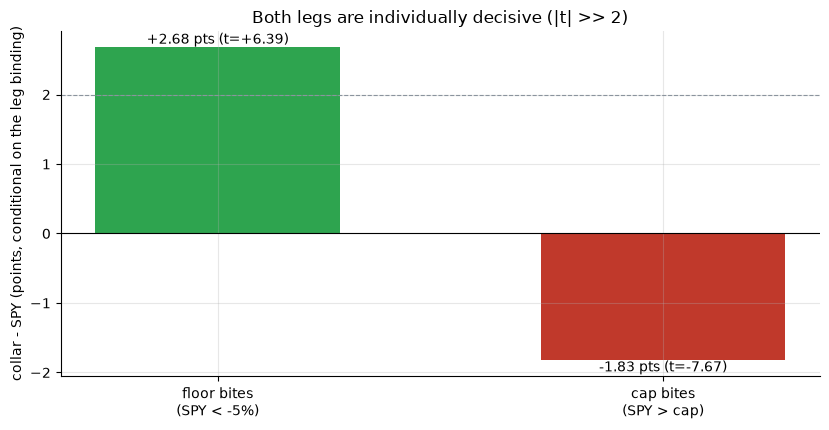

floor: n=37, +2.68 pts, t=+6.39, worst SPY -16.5% -> collar -5.1%
cap:   n=42 (10.6%), -1.83 pts, t=-7.67, best SPY given up +12.7%


In [3]:
if HAVE_REAL:
    cf = st.crash_floor_effect(DF, thresh=-data.PUT_OTM)
    cc = st.cap_cost_effect(DF)
else:
    cf = dict(n=R['floor_n'], mean_cushion_pts=R['floor_cushion'], t_plain=R['floor_t'],
              worst_spy_pct=R['floor_worst_spy'], worst_collar_pct=R['floor_worst_collar'])
    cc = dict(n=R['cap_n'], mean_cost_pts=R['cap_cost'], t_plain=R['cap_t'],
              share_of_months=R['cap_share'], best_spy_pct=R['cap_best_spy'])
fig, ax = plt.subplots(figsize=(8.4, 4.4))
vals = [cf['mean_cushion_pts'], cc['mean_cost_pts']]
ts = [cf['t_plain'], cc['t_plain']]
ax.bar(['floor bites\n(SPY < -5%)', 'cap bites\n(SPY > cap)'], vals,
       color=[GREEN, RED], width=.55)
for i,(v,t_) in enumerate(zip(vals, ts)):
    ax.annotate(f'{v:+.2f} pts (t={t_:+.2f})',(i,v),ha='center',va='bottom' if v>0 else 'top')
ax.axhline(0, c='k', lw=.8); ax.axhline(2, ls='--', c=GREY, lw=.8)
ax.set_ylabel('collar - SPY (points, conditional on the leg binding)')
ax.set_title('Both legs are individually decisive (|t| >> 2)')
plt.tight_layout(); plt.show()
print(f"floor: n={cf['n']}, {cf['mean_cushion_pts']:+.2f} pts, t={cf['t_plain']:+.2f}, "
      f"worst SPY {cf['worst_spy_pct']:+.1f}% -> collar {cf['worst_collar_pct']:+.1f}%")
print(f"cap:   n={cc['n']} ({cc['share_of_months']:.1f}%), {cc['mean_cost_pts']:+.2f} pts, "
      f"t={cc['t_plain']:+.2f}, best SPY given up {cc['best_spy_pct']:+.1f}%")

> 💡 In plain words: the floor cushions **37 crash months** by **+2.68 points on average** (t = 6.39); the cap costs **42 melt-up months** (10.6% of the sample) **-1.83 points on average** (t = -7.67). Both clear the desk bar by a wide margin — neither is noise.

### 4c · Cost sensitivity and the break-even

The full-sample mean(collar − SPY), swept across the 2-legs-per-month roll cost, with a bisected break-even.

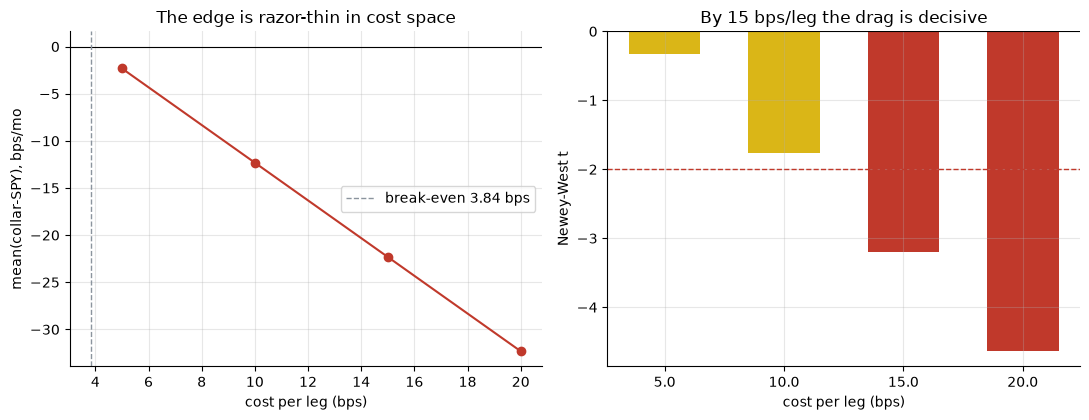

break-even: 3.84 bps/leg
{5.0: -2.3, 10.0: -12.3, 15.0: -22.3, 20.0: -32.3}


In [4]:
if HAVE_REAL:
    be = st.breakeven_cost_bps(MF['spy_ret'], MF['cap_pct'], put_otm=data.PUT_OTM)
    costs = [5.0, 10.0, 15.0, 20.0]
    diffs, ts = [], []
    for cb in costs:
        coll = st.collar_returns(MF['spy_ret'], MF['cap_pct'], put_otm=data.PUT_OTM, cost_bps=cb)
        d = pd.concat([MF, coll], axis=1)
        drag = st.full_sample_drag(d)
        diffs.append(drag['mean_diff_bps']); ts.append(drag['t_nw'])
else:
    be = R['breakeven_bps']
    costs = sorted(R['cost_table'])
    diffs = [R['cost_table'][c][0] for c in costs]
    ts = [R['cost_table'][c][2] for c in costs]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.plot(costs, diffs, 'o-', color=RED)
a1.axhline(0, c='k', lw=.8); a1.axvline(be, ls='--', c=GREY, lw=1, label=f'break-even {be:.2f} bps')
a1.set_xlabel('cost per leg (bps)'); a1.set_ylabel('mean(collar-SPY), bps/mo')
a1.set_title('The edge is razor-thin in cost space'); a1.legend()
a2.bar([str(c) for c in costs], ts, color=[RED if abs(t)>=2 else AMBER for t in ts], width=.6)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_xlabel('cost per leg (bps)'); a2.set_ylabel('Newey-West t')
a2.set_title('By 15 bps/leg the drag is decisive')
plt.tight_layout(); plt.show()
print(f'break-even: {be:.2f} bps/leg')
print({c: round(d,1) for c,d in zip(costs, diffs)})

> 💡 In plain words: break-even is **3.84 bps/leg** — thinner than the desk's own default 5 bps convention leaves comfortable room for (5 bps is already past it), and almost certainly thinner than a real OTM SPX/SPY option's bid-ask. By 15 bps the drag is decisively negative (NW t = -3.20).

### 4d · Full sample vs. the two named crashes taken out

The falsification test: does the full-sample near-wash survive removing *exactly* the two windows the claim's own marketing invokes?

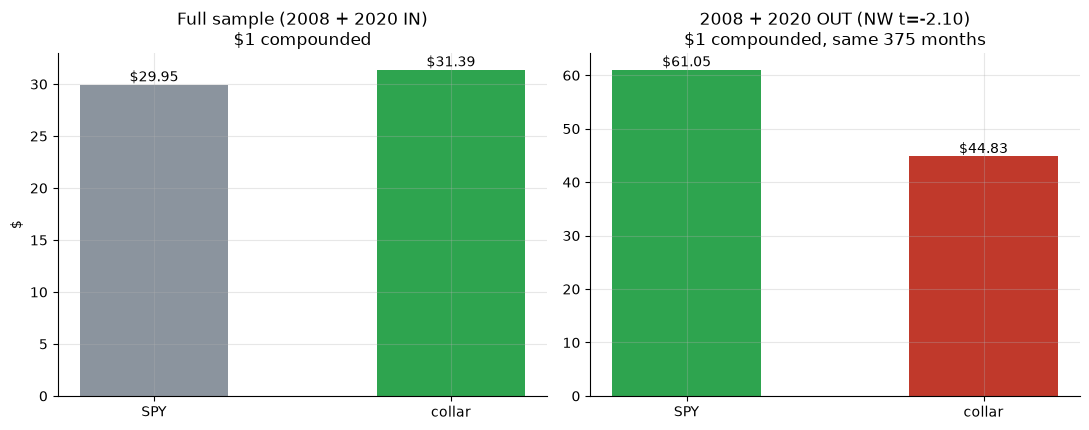

full sample: SPY $29.95  collar $31.39
ex-2008/2020: SPY $61.05  collar $44.83  (NW t=-2.10)


In [5]:
if HAVE_REAL:
    tw_spy, tw_coll = st.terminal_wealth(DF['spy_ret']), st.terminal_wealth(DF['collar_ret'])
    sub = st.exclude_windows(DF, [data.GFC_WINDOW, data.COVID_WINDOW])
    drag_sub = st.full_sample_drag(sub)
    tw_spy_sub = st.terminal_wealth(sub['spy_ret']); tw_coll_sub = st.terminal_wealth(sub['collar_ret'])
    nwt_sub = drag_sub['t_nw']
else:
    tw_spy, tw_coll = R['tw_spy'], R['tw_collar']
    tw_spy_sub, tw_coll_sub = R['exwin_tw_spy'], R['exwin_tw_collar']
    nwt_sub = R['exwin_nwt']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
a1.bar(['SPY','collar'], [tw_spy, tw_coll], color=[GREY, GREEN], width=.5)
for i,v in enumerate([tw_spy, tw_coll]): a1.annotate(f'${v:,.2f}',(i,v),ha='center',va='bottom')
a1.set_title('Full sample (2008 + 2020 IN)\n$1 compounded'); a1.set_ylabel('$')
a2.bar(['SPY','collar'], [tw_spy_sub, tw_coll_sub], color=[GREEN, RED], width=.5)
for i,v in enumerate([tw_spy_sub, tw_coll_sub]): a2.annotate(f'${v:,.2f}',(i,v),ha='center',va='bottom')
a2.set_title(f'2008 + 2020 OUT (NW t={nwt_sub:+.2f})\n$1 compounded, same 375 months')
plt.tight_layout(); plt.show()
print(f'full sample: SPY ${tw_spy:,.2f}  collar ${tw_coll:,.2f}')
print(f'ex-2008/2020: SPY ${tw_spy_sub:,.2f}  collar ${tw_coll_sub:,.2f}  (NW t={nwt_sub:+.2f})')

> 💡 In plain words: with the two crashes IN the sample, the collar edges out SPY ($31.39 vs $29.95) at a statistically insignificant gap. Pull *just* those two windows back out (dot-com bear market stays in) and SPY pulls to **$61.05** against the collar's **$44.83** — a real, HAC-robust shortfall (NW t = -2.10, stable across 0/3/6/12 lags: −1.96 / −2.10 / −2.11 / −2.15). The full-sample "win" lives entirely inside 22 specific months out of 397.

### 4e · Sharpe vs. terminal wealth — they don't have to agree

Worth stating plainly: the collar's Sharpe stays *higher* than SPY's even ex-crash, because clipping both tails lowers volatility a lot — but the number that pays your bills is terminal wealth, and that one goes the other way.

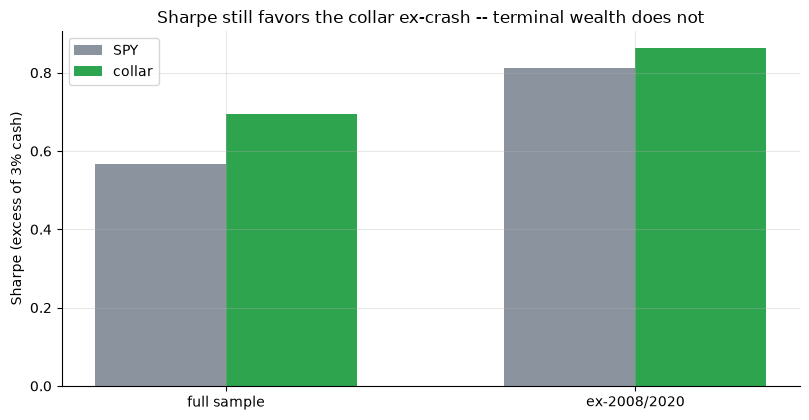

Sharpe full: SPY 0.57 vs collar 0.69
Sharpe ex-crash: SPY 0.81 vs collar 0.86


In [6]:
if HAVE_REAL:
    sh_spy = st.sharpe_excess(DF['spy_ret'], data.RF_ANNUAL)
    sh_coll = st.sharpe_excess(DF['collar_ret'], data.RF_ANNUAL)
    sh_spy_sub = st.sharpe_excess(sub['spy_ret'], data.RF_ANNUAL)
    sh_coll_sub = st.sharpe_excess(sub['collar_ret'], data.RF_ANNUAL)
else:
    sh_spy, sh_coll = R['sharpe_spy'], R['sharpe_collar']
    sh_spy_sub, sh_coll_sub = R['exwin_sh_spy'], R['exwin_sh_collar']
fig, ax = plt.subplots(figsize=(8.2, 4.3))
x = np.arange(2); w = .32
ax.bar(x-w/2, [sh_spy, sh_spy_sub], width=w, color=GREY, label='SPY')
ax.bar(x+w/2, [sh_coll, sh_coll_sub], width=w, color=GREEN, label='collar')
ax.set_xticks(x); ax.set_xticklabels(['full sample', 'ex-2008/2020'])
ax.set_ylabel('Sharpe (excess of 3% cash)')
ax.set_title('Sharpe still favors the collar ex-crash -- terminal wealth does not')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Sharpe full: SPY {sh_spy:.2f} vs collar {sh_coll:.2f}')
print(f'Sharpe ex-crash: SPY {sh_spy_sub:.2f} vs collar {sh_coll_sub:.2f}')

> 💡 In plain words: ex-crash Sharpe is **0.81** (SPY) vs **0.86** (collar) — the collar still *looks* better on a risk-adjusted basis, purely because clipping both tails cuts volatility. But the dollar outcome over the same months is **$61.05** vs **$44.83** — that's the version that matters. Sharpe rewards a smooth ride; it does not reward getting there faster. Don't let a favorable Sharpe substitute for the terminal-wealth number when someone's actually pitching you this trade.

### 4f · Faithful-engine control — the clip mechanics are unbiased

Synthetic monthly GBM (16%/yr vol, 9%/yr drift), no roll costs (isolating the clip effect from the flat-cost assumption), 20 seeds.

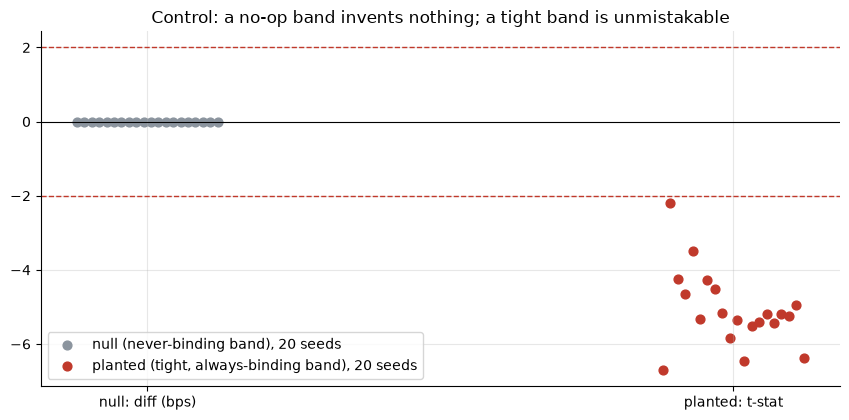

null: max |diff| across 20 seeds = 0.000000 bps (exactly zero)
planted: mean t = -5.08 (sd 1.03), |t|>=2 in 20/20 seeds


In [7]:
null_diffs = []
planted_ts = []
for s_ in range(20):
    world = data.synthetic_world(seed=659 + s_)['spy_ret']
    null_r = st.synthetic_detect(world, floor=-0.99, cap=0.99)
    null_diffs.append(null_r['mean_diff_bps'])
    planted_ts.append(st.synthetic_detect(world, floor=-0.03, cap=0.02)['t_plain'])
null_diffs = np.asarray(null_diffs); planted_ts = np.asarray(planted_ts)
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.scatter(np.zeros(20) + np.linspace(-.12,.12,20), null_diffs, color=GREY, s=40,
           label='null (never-binding band), 20 seeds')
ax.scatter(np.ones(20) + np.linspace(-.12,.12,20), planted_ts, color=RED, s=40,
           label='planted (tight, always-binding band), 20 seeds')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks([0,1]); ax.set_xticklabels(['null: diff (bps)', 'planted: t-stat'])
ax.set_title('Control: a no-op band invents nothing; a tight band is unmistakable')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: max |diff| across 20 seeds = {np.max(np.abs(null_diffs)):.6f} bps (exactly zero)')
print(f'planted: mean t = {planted_ts.mean():+.2f} (sd {planted_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(np.abs(planted_ts)>=2).sum()}/20 seeds')

> 💡 In plain words: a floor/cap wide enough to never bind at realistic vol produces **exactly zero** difference from raw returns in every single one of 20 seeds — the strongest possible non-signal. A tight, always-binding band lights up unmistakably (mean t = -5.08, 20/20 seeds clearing |t| ≥ 2). The clip-and-drag machinery reacts exactly as it should. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `MIXED`** — the floor cushions crashes (**+2.68 pts/event, t = 6.39**) and the cap costs bull months (**-1.83 pts/event, t = -7.67**), both decisively real on the tape. The net sign is regime-dependent: full sample with 2008/2020 IN, it's a wash (t = -0.34); with just those two windows OUT, it's a certified drag (NW t = -2.10).
- **Tradability `FRAGILE`** — break-even sits at a thin 3.84 bps/leg, and the entire full-sample edge is concentrated in 22 of 397 months. Neither a cost buffer nor a robustness margin survives realistic stress.
- **"Truly free protection?" `BUSTED`** — the cap's cost is mechanically guaranteed and statistically certified every time it binds, independent of whether a crash ever arrives to "justify" it. "Costless" is a statement about day-one option premiums, not about the trade you actually end up holding.

## 6 · Going further

- **The general object is insurance pricing, not this specific structure.** Any self-financing hedge (collars, put spreads financed by calls, risk-reversals) faces the same arithmetic: the premium you "don't pay" in cash you pay in forgone optionality, and whether that trade nets out ahead is a statement about realized future volatility and drawdown timing, not about the structure itself.
- **The obvious next test:** price the collar off a real, skewed implied-vol surface (once/if a historical SPX option chain is available) rather than a flat realized-vol proxy — our own reasoning in `docs/references.md` suggests this would widen the modeled cap somewhat, which would only make the cap-cost side of this study's finding *more* conservative, not less.
- **Dedup map:** [617-crash-insurance-cost](../../617-crash-insurance-cost/) (the naked put, no financing), [658-put-write-premium](../../658-put-write-premium/) (the mirror-image short-put trade), [337-covered-call-etf](../../337-covered-call-etf/) (this collar with the put leg removed), [99-safety-net](../../99-safety-net/) (protection via exit rules, no options at all).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*